In [80]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [81]:
validator_exits_size = pd.read_csv('../int/validator_exits_size.csv')
validator_exits_category = pd.read_csv('../int/validator_exits_category.csv')
active_validators_size = pd.read_csv('../int/active_validators_size.csv')
active_validators_category = pd.read_csv('../int/active_validators_category.csv')

active_validators_size = active_validators_size[active_validators_size['slot'] >= 6206400]
active_validators_category = active_validators_category[active_validators_category['slot'] >= 6206400]

In [82]:
rewards_size = pd.read_csv('../int/rewards_size.csv', usecols=('1', '2-5', '6-19', '20-99', '100+', 'slot'))
rewards_category = pd.read_csv('../int/rewards_category.csv', usecols=('slot', 'CEX', 'Liquid Restaking', 'Liquid Staking', 'Solo Stakers', 'Staking Pools'))

columns_to_compare = ['1', '2-5', '20-99', '6-19']
reference_column = '100+'

# Calculate the percentage difference compared to '100+'
for col in columns_to_compare:
    rewards_size[f'{col}'] = ((rewards_size[col] - rewards_size[reference_column]) / rewards_size[reference_column])

# Display the updated DataFrame
rewards_size = rewards_size.drop(columns=('100+'))
rewards_size

,1,2-5,20-99,6-19,slot
0,-0.083660,-0.055338,-0.047796,-0.046120,6840000.0
1,-0.092545,-0.053869,-0.027007,-0.033781,6847200.0
2,-0.099121,-0.057609,-0.020304,-0.039100,6854400.0
3,-0.096569,-0.051269,-0.005204,-0.004774,6861600.0
4,-0.106205,-0.045752,-0.018268,-0.041452,6868800.0
...,...,...,...,...,...
305,-0.058212,-0.043316,-0.009880,-0.026945,9036000.0
306,-0.089827,-0.017991,-0.015707,-0.026361,9043200.0
307,-0.054577,-0.045717,-0.007851,-0.038246,9050400.0
308,-0.048790,-0.054600,-0.006384,-0.032202,9057600.0


In [83]:
# List of columns to calculate the percentage difference for
columns_to_compare = ['CEX', 'Liquid Restaking', 'Liquid Staking', 'Staking Pools']
reference_column = 'Solo Stakers'

# Calculate the percentage difference compared to 'Solo Stakers'
for col in columns_to_compare:
    rewards_category[f'{col}'] = ((rewards_category[col] - rewards_category[reference_column]) / rewards_category[reference_column])

# Display the updated DataFrame
rewards_category = rewards_category.drop(columns=('Solo Stakers'))
rewards_category

,CEX,Liquid Restaking,Liquid Staking,Staking Pools,slot
0,0.023092,0.155633,0.018398,0.013659,6840000.0
1,0.001797,-0.081280,0.009366,-0.028981,6847200.0
2,0.008096,0.043643,-0.003074,-0.066223,6854400.0
3,0.016137,0.015077,0.012642,-0.025550,6861600.0
4,0.017817,0.098902,0.015241,-0.037005,6868800.0
...,...,...,...,...,...
305,0.039095,0.038991,0.041325,0.033833,9036000.0
306,0.025797,0.033104,0.028897,0.023247,9043200.0
307,-0.022743,-0.029122,-0.013271,-0.020381,9050400.0
308,-0.004024,0.013929,0.007861,0.012043,9057600.0


In [84]:
validator_exits_size_set = validator_exits_size
validator_exits_size_set['slot'] = validator_exits_size_set['slot'] // 7200 * 7200

# Group by the day and get the last slot of each day and sum values for all columns
validator_exits_size_set = validator_exits_size_set.groupby('slot').agg(
    {
        'slot': 'last',
        '1': 'sum',
        '2-5': 'sum',
        '6-19': 'sum',
        '20-99': 'sum',
        '100+': 'sum',
    }
).reset_index(drop=True)

validator_exits_size_set


,slot,1,2-5,6-19,20-99,100+
0,0.0,0.0,0.0,0.0,1.0,0.0
1,7200.0,0.0,0.0,0.0,0.0,0.0
2,14400.0,0.0,0.0,0.0,0.0,10.0
3,21600.0,0.0,0.0,1.0,0.0,0.0
4,28800.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
1244,8956800.0,2.0,10.0,7.0,8.0,437.0
1245,8964000.0,11.0,7.0,10.0,6.0,1447.0
1246,8971200.0,99.0,11.0,19.0,96.0,1151.0
1247,8978400.0,9.0,8.0,1.0,7.0,669.0


In [85]:
validator_exits_category_set = validator_exits_category
validator_exits_category_set['slot'] = validator_exits_category_set['slot'] // 7200 * 7200

# Create a dictionary for aggregation
agg_dict = {col: 'sum' for col in validator_exits_category_set.columns if col != 'slot'}
agg_dict['slot'] = 'last'

# Group by 'slot' and apply the aggregation
validator_exits_category_set = validator_exits_category_set.groupby('slot').agg(agg_dict).reset_index(drop=True)

validator_exits_category_set

,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unidentified,total,slot
0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7200.0
2,0.0,0.0,10.0,0.0,0.0,0.0,10.0,14400.0
3,0.0,0.0,0.0,0.0,0.0,1.0,1.0,21600.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28800.0
...,...,...,...,...,...,...,...,...
1244,310.0,0.0,16.0,4.0,111.0,23.0,464.0,8956800.0
1245,300.0,361.0,150.0,0.0,568.0,102.0,1481.0,8964000.0
1246,341.0,50.0,188.0,2.0,20.0,775.0,1376.0,8971200.0
1247,94.0,0.0,182.0,0.0,34.0,384.0,694.0,8978400.0


In [86]:
active_validators_size_set = active_validators_size[active_validators_size['slot'].isin(validator_exits_size_set['slot'])]
active_validators_size_set.reset_index(inplace=True)
active_validators_size_set = active_validators_size_set.drop(columns=['index'])
active_validators_size_set

,slot,1,100+,2-5,20-99,6-19,total
0,6206400.0,6648.0,508415.0,8434.0,26693.0,12655.0,562845.0
1,6213600.0,6622.0,507748.0,8434.0,26846.0,12671.0,562321.0
2,6220800.0,6623.0,507027.0,8447.0,26891.0,12667.0,561655.0
3,6228000.0,6629.0,506934.0,8452.0,26964.0,12676.0,561655.0
4,6235200.0,6633.0,506690.0,8453.0,27176.0,12703.0,561655.0
...,...,...,...,...,...,...,...
382,8956800.0,9865.0,917054.0,9915.0,44138.0,17998.0,998970.0
383,8964000.0,9894.0,918299.0,9914.0,44152.0,18033.0,1000292.0
384,8971200.0,9898.0,918498.0,9920.0,44277.0,18033.0,1000626.0
385,8978400.0,9824.0,918915.0,9926.0,44343.0,18042.0,1001050.0


In [87]:
active_validators_category_set = active_validators_category[active_validators_category['slot'].isin(validator_exits_category_set['slot'])]
active_validators_category_set.reset_index(inplace=True)
active_validators_category_set = active_validators_category_set.drop(columns=['index'])
active_validators_category_set

,slot,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unidentified,total
0,6206400.0,197661.0,8.0,203116.0,21557.0,26183.0,114320.0,562845.0
1,6213600.0,196665.0,8.0,203302.0,21564.0,26201.0,114581.0,562321.0
2,6220800.0,195247.0,8.0,203313.0,21564.0,26261.0,115262.0,561655.0
3,6228000.0,194313.0,8.0,203187.0,21575.0,26304.0,116268.0,561655.0
4,6235200.0,193376.0,8.0,203190.0,21618.0,26385.0,117078.0,561655.0
...,...,...,...,...,...,...,...,...
382,8956800.0,255557.0,75916.0,331402.0,16812.0,57077.0,262206.0,998970.0
383,8964000.0,255875.0,76685.0,331441.0,16819.0,56993.0,262479.0,1000292.0
384,8971200.0,256042.0,77041.0,331314.0,16821.0,56440.0,262968.0,1000626.0
385,8978400.0,255922.0,77313.0,331173.0,16827.0,56445.0,263370.0,1001050.0


In [88]:
validator_exits_size_set.set_index('slot', inplace=True)
active_validators_size_set.set_index('slot', inplace=True)
validator_exit_percentage_size = validator_exits_size_set.divide(active_validators_size_set, fill_value=0) * 100
validator_exit_percentage_size.reset_index(inplace=True)
validator_exit_percentage_size = validator_exit_percentage_size.drop(columns=('100+'))

In [89]:
validator_exit_percentage_size

,slot,1,2-5,20-99,6-19,total
0,0.0,NaN,NaN,inf,NaN,NaN
1,7200.0,NaN,NaN,NaN,NaN,NaN
2,14400.0,NaN,NaN,NaN,NaN,NaN
3,21600.0,NaN,NaN,NaN,inf,NaN
4,28800.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1244,8956800.0,0.020274,0.100857,0.018125,0.038893,0.0
1245,8964000.0,0.111178,0.070607,0.013589,0.055454,0.0
1246,8971200.0,1.000202,0.110887,0.216817,0.105362,0.0
1247,8978400.0,0.091612,0.080596,0.015786,0.005543,0.0


In [90]:
validator_exits_category_set.set_index('slot', inplace=True)
active_validators_category_set.set_index('slot', inplace=True)
validator_exit_percentage_category = validator_exits_category_set.divide(active_validators_category_set, fill_value=0) * 100
validator_exit_percentage_category.reset_index(inplace=True)

validator_exit_percentage_category

,slot,CEX,Liquid Restaking,Liquid Staking,Solo Stakers,Staking Pools,Unidentified,total
0,0.0,NaN,NaN,NaN,NaN,NaN,inf,inf
1,7200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,14400.0,NaN,NaN,inf,NaN,NaN,NaN,inf
3,21600.0,NaN,NaN,NaN,NaN,NaN,inf,inf
4,28800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1244,8956800.0,0.121304,0.000000,0.004828,0.023793,0.194474,0.008772,0.046448
1245,8964000.0,0.117245,0.470757,0.045257,0.000000,0.996614,0.038860,0.148057
1246,8971200.0,0.133181,0.064901,0.056744,0.011890,0.035436,0.294713,0.137514
1247,8978400.0,0.036730,0.000000,0.054956,0.000000,0.060236,0.145802,0.069327


In [91]:
validator_exit_percentage_category.replace([np.inf, -np.inf], np.nan, inplace=True)
validator_exit_percentage_category[['slot', 'Solo Stakers']].dropna()

,slot,Solo Stakers
862,6206400.0,0.000000
863,6213600.0,0.018549
864,6220800.0,0.004637
865,6228000.0,0.023175
866,6235200.0,0.000000
...,...,...
1244,8956800.0,0.023793
1245,8964000.0,0.000000
1246,8971200.0,0.011890
1247,8978400.0,0.000000


In [94]:
active_validators_size.columns

Index(['slot', '1', '100+', '2-5', '20-99', '6-19', 'total'], dtype='object')

In [95]:
price_elasticity_size

,slot,1_x,2-5_x,20-99_x,6-19_x,total,1_y,2-5_y,20-99_y,6-19_y
1,6847200.0,0.045045,0.046275,0.000000,0.000000,0.0,0.106203,-0.026545,-0.434945,-0.267547
2,6854400.0,0.090117,0.034706,0.111831,0.143875,0.0,0.071060,0.069417,-0.248192,0.157459
3,6861600.0,0.120265,0.057864,0.032928,0.043212,0.0,-0.025746,-0.110044,-0.743720,-0.877904
4,6868800.0,0.030102,0.196850,0.003294,0.072046,0.0,0.099780,-0.107608,2.510610,7.683057
5,6876000.0,0.045160,0.092818,0.082351,0.021629,0.0,-0.058233,-0.067603,-0.288044,0.474910
...,...,...,...,...,...,...,...,...,...,...
294,8956800.0,0.020274,0.100857,0.018125,0.038893,0.0,0.273888,0.921551,-1.035509,-0.399818
295,8964000.0,0.111178,0.070607,0.013589,0.055454,0.0,-0.802258,-0.135908,2.910836,0.233804
296,8971200.0,1.000202,0.110887,0.216817,0.105362,0.0,3.800535,1.124607,-9.697641,-0.241327
297,8978400.0,0.091612,0.080596,0.015786,0.005543,0.0,0.011874,-0.228341,-1.029523,0.251634


In [102]:
columns = active_validators_size.columns.drop(['slot', '100+', 'total'])
columns

Index(['1', '2-5', '20-99', '6-19'], dtype='object')

In [112]:
validator_exit_percentage_size = validator_exit_percentage_size.drop(columns=('total'))

In [115]:
price_elasticity_size

,slot,1_x,2-5_x,20-99_x,6-19_x,1_y,2-5_y,20-99_y,6-19_y
1,6847200.0,0.045045,0.046275,0.000000,0.000000,0.106203,-0.026545,-0.434945,-0.267547
2,6854400.0,0.090117,0.034706,0.111831,0.143875,0.071060,0.069417,-0.248192,0.157459
3,6861600.0,0.120265,0.057864,0.032928,0.043212,-0.025746,-0.110044,-0.743720,-0.877904
4,6868800.0,0.030102,0.196850,0.003294,0.072046,0.099780,-0.107608,2.510610,7.683057
5,6876000.0,0.045160,0.092818,0.082351,0.021629,-0.058233,-0.067603,-0.288044,0.474910
...,...,...,...,...,...,...,...,...,...
294,8956800.0,0.020274,0.100857,0.018125,0.038893,0.273888,0.921551,-1.035509,-0.399818
295,8964000.0,0.111178,0.070607,0.013589,0.055454,-0.802258,-0.135908,2.910836,0.233804
296,8971200.0,1.000202,0.110887,0.216817,0.105362,3.800535,1.124607,-9.697641,-0.241327
297,8978400.0,0.091612,0.080596,0.015786,0.005543,0.011874,-0.228341,-1.029523,0.251634


In [117]:
import numpy as np
import pandas as pd
from scipy import stats

# Calculate the percent change of APY
rewards_size_pct_change = rewards_size.set_index('slot').pct_change().reset_index()

# Merge the two DataFrames on the slot column
price_elasticity_size = pd.merge(validator_exit_percentage_size, rewards_size_pct_change, on='slot')

# Replace infinite values with NaN
price_elasticity_size.replace([np.inf, -np.inf], np.nan, inplace=True)

# Initialize dictionaries to store the results
elasticity = {}
t_stats = {}
standard_deviations = {}
p_values = {}
counts = {}
correlations = {}

# Calculate elasticity and correlation for each column
columns = active_validators_size.columns.drop(['slot', '100+', 'total'])
for col in columns:
    price_elasticity_size[f'elasticity_{col}'] = price_elasticity_size[f'{col}_x'] / price_elasticity_size[f'{col}_y']
    
    # Drop NaN values for the specific column
    valid_elasticity = price_elasticity_size[[f'elasticity_{col}', f'{col}_x', f'{col}_y']].dropna()
    
    # Store the results
    elasticity[col] = valid_elasticity[f'elasticity_{col}'].mean()
    standard_deviations[col] = valid_elasticity[f'elasticity_{col}'].std()
    counts[col] = valid_elasticity[f'elasticity_{col}'].count()
    
    # Perform a one-sample t-test against zero
    t_stat, p_value = stats.ttest_1samp(valid_elasticity[f'elasticity_{col}'], 0)
    t_stats[col] = t_stat
    p_values[col] = p_value
    
    # Calculate the correlation coefficient
    correlation, _ = stats.pearsonr(valid_elasticity[f'{col}_x'], valid_elasticity[f'elasticity_{col}'])
    correlations[col] = correlation

# Print the results
print("Elasticity Analysis Results:")
for col in columns:
    print(f'{col}: Mean Elasticity = {elasticity[col]}, t-stat = {t_stats[col]}, Std Dev = {standard_deviations[col]}, P-value = {p_values[col]}, Count = {counts[col]}, Correlation Coefficient = {correlations[col]}')

# Display the DataFrame with elasticity columns (optional)
print(price_elasticity_size)


Elasticity Analysis Results:
1: Mean Elasticity = 0.8184105104738639, t-stat = 1.2027172199055893, Std Dev = 11.746697938651689, P-value = 0.23004369835697921, Count = 298, Correlation Coefficient = -0.037600698782156695
2-5: Mean Elasticity = 0.06288445969373341, t-stat = 0.7730956721669728, Std Dev = 1.4041652589129785, P-value = 0.4400806022002346, Count = 298, Correlation Coefficient = -0.0830063018083039
20-99: Mean Elasticity = -0.19495173980922978, t-stat = -0.815935857074436, Std Dev = 4.124575220684367, P-value = 0.4151907216331189, Count = 298, Correlation Coefficient = -0.17179636048126287
6-19: Mean Elasticity = 0.16857660150498946, t-stat = 0.4853061499954775, Std Dev = 5.996386688180839, P-value = 0.6278169793737103, Count = 298, Correlation Coefficient = 0.2812939347717587
          slot       1_x     2-5_x   20-99_x    6-19_x       1_y     2-5_y  \
0    6840000.0  0.075053  0.034742  0.066540  0.000000       NaN       NaN   
1    6847200.0  0.045045  0.046275  0.000000 

In [118]:
import numpy as np
import pandas as pd
from scipy import stats

# Assuming the DataFrames are already defined and loaded
# validator_exit_percentage_size and rewards_size

# Calculate the percent change for the rewards_size DataFrame
rewards_size_pct_change = rewards_size.set_index('slot').pct_change().reset_index()

# Merge the DataFrames on the slot column for percent change calculations
price_elasticity_size = pd.merge(validator_exit_percentage_size, rewards_size_pct_change, on='slot')

# Replace infinite values with NaN and drop rows with NaN values for elasticity calculations
price_elasticity_size.replace([np.inf, -np.inf], np.nan, inplace=True)
price_elasticity_size.dropna(inplace=True)

# Merge the original DataFrames on the slot column for correlation calculations
merged_df = pd.merge(validator_exit_percentage_size, rewards_size, on='slot', suffixes=('_exit', '_apy'))

# Replace infinite values with NaN for correlation calculations
merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Initialize dictionaries to store the results
elasticity = {}
t_stats = {}
standard_deviations = {}
p_values = {}
counts = {}
correlations = {}

# List of columns to calculate elasticity and correlation for
columns = validator_exit_percentage_size.columns.drop(['slot'])
for col in columns:
    price_elasticity_size[f'elasticity_{col}'] = price_elasticity_size[f'{col}_x'] / price_elasticity_size[f'{col}_y']
    
    # Drop NaN values for the specific column for elasticity calculations
    valid_elasticity = price_elasticity_size[f'elasticity_{col}'].dropna()
    
    # Store the results for elasticity
    elasticity[col] = valid_elasticity.mean()
    standard_deviations[col] = valid_elasticity.std()
    counts[col] = valid_elasticity.count()
    
    # Perform a one-sample t-test against zero
    t_stat, p_value = stats.ttest_1samp(valid_elasticity, 0)
    t_stats[col] = t_stat
    p_values[col] = p_value
    
    # Calculate the correlation coefficient using non-percent change values
    correlation, _ = stats.pearsonr(merged_df[f'{col}_exit'], merged_df[f'{col}_apy'])
    correlations[col] = correlation

# Print the results
print("Elasticity and Correlation Analysis Results:")
for col in columns:
    print(f'{col}: Mean Elasticity = {elasticity[col]}, t-stat = {t_stats[col]}, Std Dev = {standard_deviations[col]}, P-value = {p_values[col]}, Count = {counts[col]}, Correlation Coefficient = {correlations[col]}')

# Display the DataFrame with elasticity columns (optional)
print(price_elasticity_size)

Elasticity and Correlation Analysis Results:
1: Mean Elasticity = 0.8184105104738639, t-stat = 1.2027172199055893, Std Dev = 11.746697938651689, P-value = 0.23004369835697921, Count = 298, Correlation Coefficient = 0.08496793368159182
2-5: Mean Elasticity = 0.06288445969373341, t-stat = 0.7730956721669728, Std Dev = 1.4041652589129785, P-value = 0.4400806022002346, Count = 298, Correlation Coefficient = -0.028826323258641883
20-99: Mean Elasticity = -0.19495173980922978, t-stat = -0.815935857074436, Std Dev = 4.124575220684367, P-value = 0.4151907216331189, Count = 298, Correlation Coefficient = -0.022717144694370757
6-19: Mean Elasticity = 0.16857660150498946, t-stat = 0.4853061499954775, Std Dev = 5.996386688180839, P-value = 0.6278169793737103, Count = 298, Correlation Coefficient = 0.05508900562005358
          slot       1_x     2-5_x   20-99_x    6-19_x       1_y     2-5_y  \
1    6847200.0  0.045045  0.046275  0.000000  0.000000  0.106203 -0.026545   
2    6854400.0  0.090117  0

In [123]:
rewards_category_pct_change

,slot,CEX,Liquid Restaking,Liquid Staking,Staking Pools
0,6840000.0,NaN,NaN,NaN,NaN
1,6847200.0,-0.922164,-1.522252,-0.490931,-3.121697
2,6854400.0,3.504339,-1.536951,-1.328233,1.285059
3,6861600.0,0.993245,-0.654528,-5.112316,-0.614180
4,6868800.0,0.104075,5.559571,0.205622,0.448332
...,...,...,...,...,...
305,9036000.0,0.205999,-0.149045,0.230559,0.168721
306,9043200.0,-0.340144,-0.150999,-0.300748,-0.312896
307,9050400.0,-1.881629,-1.879714,-1.459243,-1.876694
308,9057600.0,-0.823075,-1.478297,-1.592334,-1.590927


In [124]:
import numpy as np
import pandas as pd
from scipy import stats

# Assuming the DataFrames are already defined and loaded
# validator_exit_percentage_category and rewards_category

# Calculate the percent change for the rewards_category DataFrame
rewards_category_pct_change = rewards_category.set_index('slot').pct_change().reset_index()

# Merge the DataFrames on the slot column
merged_df = pd.merge(validator_exit_percentage_category[['slot', 'Solo Stakers']], rewards_category_pct_change, on='slot')

# Replace infinite values with NaN and drop rows with NaN values
merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)
merged_df.dropna(inplace=True)

# Initialize dictionaries to store the results
elasticity = {}
t_stats = {}
standard_deviations = {}
p_values = {}
counts = {}
correlations = {}

# List of columns to calculate elasticity and correlation for
columns = ['CEX', 'Liquid Restaking', 'Liquid Staking', 'Staking Pools']
reference_column = 'Solo Stakers'

# Calculate elasticity and correlation for each column
for col in columns:
    merged_df[f'elasticity_{col}'] = merged_df[reference_column] / merged_df[f'{col}']
    
    # Drop NaN values for the specific column
    valid_elasticity = merged_df[[f'elasticity_{col}', reference_column, f'{col}']].dropna()
    
    # Store the results
    elasticity[col] = valid_elasticity[f'elasticity_{col}'].mean()
    standard_deviations[col] = valid_elasticity[f'elasticity_{col}'].std()
    counts[col] = valid_elasticity[f'elasticity_{col}'].count()
    
    # Perform a one-sample t-test against zero
    t_stat, p_value = stats.ttest_1samp(valid_elasticity[f'elasticity_{col}'], 0)
    t_stats[col] = t_stat
    p_values[col] = p_value
    
    # Calculate the correlation coefficient
    correlation, _ = stats.pearsonr(valid_elasticity[reference_column], valid_elasticity[f'elasticity_{col}'])
    correlations[col] = correlation

# Print the results
print("Elasticity and Correlation Analysis Results:")
for col in columns:
    print(f'{col}: Mean Elasticity = {elasticity[col]}, t-stat = {t_stats[col]}, Std Dev = {standard_deviations[col]}, P-value = {p_values[col]}, Count = {counts[col]}, Correlation Coefficient = {correlations[col]}')

# Display the merged DataFrame with elasticity columns (optional)
merged_df

Elasticity and Correlation Analysis Results:
CEX: Mean Elasticity = 0.12043059203384666, t-stat = 1.2404116309946491, Std Dev = 1.6760197173524334, P-value = 0.21580219220289748, Count = 298, Correlation Coefficient = 0.4099264197009628
Liquid Restaking: Mean Elasticity = -0.0774335585066467, t-stat = -1.222052213754434, Std Dev = 1.0938243520411868, P-value = 0.22265688229392858, Count = 298, Correlation Coefficient = 0.22336713607906766
Liquid Staking: Mean Elasticity = 0.26807291439676256, t-stat = 1.3939534226157644, Std Dev = 3.319806763268449, P-value = 0.1643737054560803, Count = 298, Correlation Coefficient = 0.333120083596379
Staking Pools: Mean Elasticity = 0.3922113384380569, t-stat = 0.9488071357407702, Std Dev = 7.135925943940362, P-value = 0.3434900996660747, Count = 298, Correlation Coefficient = 0.17859450689832934


,slot,Solo Stakers,CEX,Liquid Restaking,Liquid Staking,Staking Pools,elasticity_CEX,elasticity_Liquid Restaking,elasticity_Liquid Staking,elasticity_Staking Pools
1,6847200.0,0.000000,-0.922164,-1.522252,-0.490931,-3.121697,-0.000000,-0.000000,-0.000000,-0.000000
2,6854400.0,0.004404,3.504339,-1.536951,-1.328233,1.285059,0.001257,-0.002865,-0.003316,0.003427
3,6861600.0,0.013213,0.993245,-0.654528,-5.112316,-0.614180,0.013303,-0.020187,-0.002585,-0.021513
4,6868800.0,0.000000,0.104075,5.559571,0.205622,0.448332,0.000000,0.000000,0.000000,0.000000
5,6876000.0,0.000000,-0.119324,-2.254053,-0.052791,-0.292957,-0.000000,-0.000000,-0.000000,-0.000000
...,...,...,...,...,...,...,...,...,...,...
294,8956800.0,0.023793,-1.151574,-0.359638,4.759802,1.630144,-0.020661,-0.066157,0.004999,0.014595
295,8964000.0,0.000000,-26.306754,3.005298,1.544293,0.249046,-0.000000,0.000000,0.000000,0.000000
296,8971200.0,0.011890,-0.872218,-1.097384,-1.088783,-0.708224,-0.013632,-0.010835,-0.010920,-0.016788
297,8978400.0,0.000000,13.435862,-27.202966,-14.186493,4.988381,0.000000,-0.000000,-0.000000,0.000000


In [126]:
import numpy as np
import pandas as pd
from scipy import stats

# Assuming the DataFrames are already defined and loaded
# validator_exit_percentage_category and rewards_category

# Calculate the percent change for the rewards_category DataFrame
rewards_category_pct_change = rewards_category.set_index('slot').pct_change().reset_index()

# Merge the DataFrames on the slot column for percent change calculations (elasticity)
elasticity_df = pd.merge(validator_exit_percentage_category[['slot', 'Solo Stakers']], rewards_category_pct_change, on='slot')

# Merge the DataFrames on the slot column for original values (correlation)
correlation_df = pd.merge(validator_exit_percentage_category[['slot', 'Solo Stakers']], rewards_category, on='slot')

# Replace infinite values with NaN and drop rows with NaN values for elasticity calculations
elasticity_df.replace([np.inf, -np.inf], np.nan, inplace=True)
elasticity_df.dropna(inplace=True)

# Replace infinite values with NaN for correlation calculations
correlation_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Initialize dictionaries to store the results
elasticity = {}
t_stats = {}
standard_deviations = {}
p_values = {}
counts = {}
correlations = {}

# List of columns to calculate elasticity and correlation for
columns = ['CEX', 'Liquid Restaking', 'Liquid Staking', 'Staking Pools']
reference_column = 'Solo Stakers'

# Calculate elasticity and correlation for each column
for col in columns:
    # Calculate elasticity using percent change values
    elasticity_df[f'elasticity_{col}'] = elasticity_df[reference_column] / elasticity_df[f'{col}']
    
    # Drop NaN values for the specific column for elasticity calculations
    valid_elasticity = elasticity_df[[f'elasticity_{col}', reference_column, f'{col}']].dropna()
    
    # Store the results for elasticity
    elasticity[col] = valid_elasticity[f'elasticity_{col}'].mean()
    standard_deviations[col] = valid_elasticity[f'elasticity_{col}'].std()
    counts[col] = valid_elasticity[f'elasticity_{col}'].count()
    
    # Perform a one-sample t-test against zero
    t_stat, p_value = stats.ttest_1samp(valid_elasticity[f'elasticity_{col}'], 0)
    t_stats[col] = t_stat
    p_values[col] = p_value
    
    # Calculate the correlation coefficient using non-percent change values
    valid_correlation = correlation_df[[reference_column, col]].dropna()
    correlation, _ = stats.pearsonr(valid_correlation[reference_column], valid_correlation[col])
    correlations[col] = correlation

# Print the results
print("Elasticity and Correlation Analysis Results:")
for col in columns:
    print(f'{col}: Mean Elasticity = {elasticity[col]}, t-stat = {t_stats[col]}, Std Dev = {standard_deviations[col]}, P-value = {p_values[col]}, Count = {counts[col]}, Correlation Coefficient = {correlations[col]}')

# Display the DataFrame with elasticity columns (optional)
print(elasticity_df)
print(correlation_df)


Elasticity and Correlation Analysis Results:
CEX: Mean Elasticity = 0.12043059203384666, t-stat = 1.2404116309946491, Std Dev = 1.6760197173524334, P-value = 0.21580219220289748, Count = 298, Correlation Coefficient = 0.35104165337793686
Liquid Restaking: Mean Elasticity = -0.0774335585066467, t-stat = -1.222052213754434, Std Dev = 1.0938243520411868, P-value = 0.22265688229392858, Count = 298, Correlation Coefficient = 0.17113970996568642
Liquid Staking: Mean Elasticity = 0.26807291439676256, t-stat = 1.3939534226157644, Std Dev = 3.319806763268449, P-value = 0.1643737054560803, Count = 298, Correlation Coefficient = 0.34754571438174453
Staking Pools: Mean Elasticity = 0.3922113384380569, t-stat = 0.9488071357407702, Std Dev = 7.135925943940362, P-value = 0.3434900996660747, Count = 298, Correlation Coefficient = 0.28429957226204605
          slot  Solo Stakers        CEX  Liquid Restaking  Liquid Staking  \
1    6847200.0      0.000000  -0.922164         -1.522252       -0.490931   


In [ ]:
rewards_size_g = rewards_size.copy()
# Set 'slot' as the index for plotting
rewards_size_g.set_index('slot', inplace=True)

# Plot all columns by slot
plt.figure(figsize=(12, 6))
for column in rewards_size_g.columns:
    plt.plot(rewards_size_g.index, rewards_size_g[column], label=column)

plt.xlabel('Slot')
plt.ylabel('Value')
plt.title('Values by Slot')
plt.legend(title='Columns')
plt.grid(True)
plt.show()

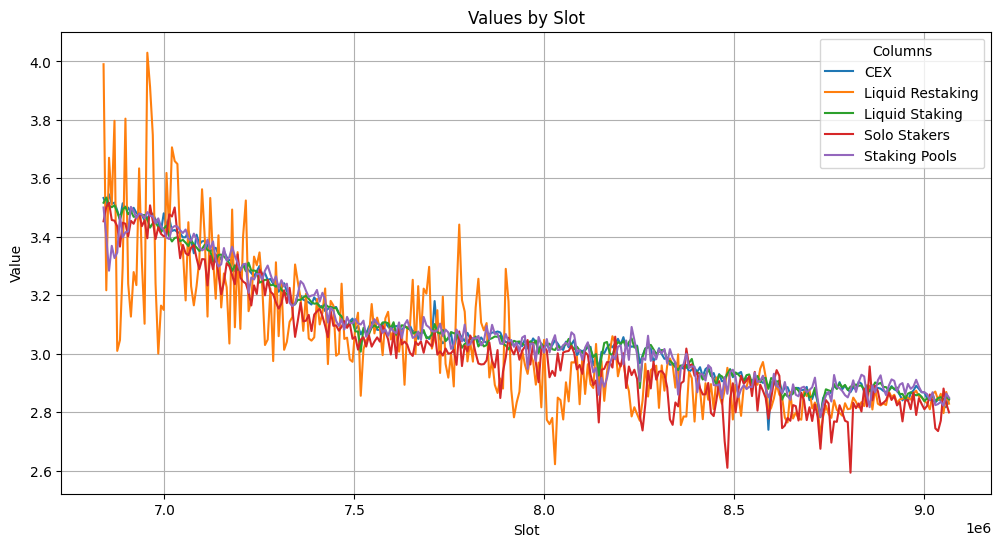

In [ ]:
rewards_category_g = rewards_category.copy()
# Set 'slot' as the index for plotting
rewards_category_g.set_index('slot', inplace=True)

# Plot all columns by slot
plt.figure(figsize=(12, 6))
for column in rewards_category_g.columns:
    plt.plot(rewards_category_g.index, rewards_category_g[column], label=column)

plt.xlabel('Slot')
plt.ylabel('Value')
plt.title('Values by Slot')
plt.legend(title='Columns')
plt.grid(True)
plt.show()